# PraNet training on PolypDB for Google Colab

This notebook is organized in **separate debug-friendly blocks** so you can run step by step, inspect outputs, and fix issues without restarting everything.

**Outputs generated**
- `pranet_polypdb_best.pth`
- `pranet_training_history.csv`
- `pranet_summary_metrics.json`
- `pranet_results_bundle.zip`

At the end, the files are downloaded to your local machine.

## Block 1 — Install dependencies

Run this first. If this block fails, fix the package issue before continuing.

In [ ]:
!pip -q install kagglehub albumentations timm opencv-python scikit-learn

## Block 2 — Imports and global config

In [ ]:
import os
import re
import cv2
import json
import random
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A

from google.colab import files
import kagglehub

SEED = 42
IMG_SIZE = 352
BATCH_SIZE = 8
EPOCHS = 100
LR = 1e-4
VAL_SPLIT = 0.20
NUM_WORKERS = 2
THRESHOLD = 0.5

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Block 3 — Download PolypDB

This block downloads the dataset and stores its root path in `path`.

In [ ]:
path = kagglehub.dataset_download("debeshjha1/polypdb")
print("Dataset path:", path)

100%|██████████| 1.29G/1.29G [00:07<00:00, 188MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1


## Block 4 — Inspect dataset tree

Use this when debugging folder names.

In [ ]:
def print_tree(root, max_depth=5):
    root = os.path.abspath(root)
    base_depth = root.count(os.sep)

    for current_root, dirs, files in os.walk(root):
        depth = current_root.count(os.sep) - base_depth
        if depth > max_depth:
            continue

        indent = "  " * depth
        print(f"{indent}📁 {os.path.basename(current_root)}/")
        for f in files[:5]:
            print(f"{indent}  📄 {f}")

print_tree(path, max_depth=5)

📁 1/
  📁 PolypDB/
    📁 PolypDB/
      📁 PolypDB_center_wise/
        📁 Karolinska/
          📁 WLI/
        📁 Simula/
          📁 WLI/
          📁 NBI/
        📁 BKAI/
          📁 WLI/
          📁 FICE/
          📁 BLI/
          📁 LCI/
      📁 PolypDB_modality_wise/
        📁 WLI/
          📁 images/
            📄 HMUH_06 200731_200724_BN064_002.jpg
            📄 1cb0543a-89d3-4d20-85d9-2ce6c30e09ba.jpg
            📄 4d944bd1-7dda-45c6-b6fc-75fe9974862d.jpg
            📄 c6eac89d-86ed-46be-9580-5a0fe8551f11.jpg
            📄 1a584425-b05f-4e74-a483-c6d736d5ff0b.jpg
          📁 masks/
            📄 HMUH_09 200908_200828_BN046_003.png
            📄 HMUH_06 200731_200720_BN018_003.png
            📄 07c03e94-a0e8-4139-9ae9-e57336ef75d1.png
            📄 db6bfedd-976b-4ea2-896a-efc5f50311c5.png
            📄 HMUH_07 200808_200804_BN028_011.png
        📁 FICE/
          📁 images/
            📄 HMUH_16 201207_201126_BN001_001.jpg
            📄 HMUH_16 201207_201128_BN007_002.jpg
           

## Block 5 — Auto-detect image and mask folders

If pairing fails later, review the printed candidates here.

In [ ]:
def collect_files_recursive(folder, exts=(".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
    folder = Path(folder)
    files = []
    for ext in exts:
        files.extend(folder.rglob(f"*{ext}"))
        files.extend(folder.rglob(f"*{ext.upper()}"))
    return sorted(list(set(files)))

def detect_candidate_dirs(root):
    candidate_image_dirs = []
    candidate_mask_dirs = []

    for current_root, dirs, files in os.walk(root):
        if not files:
            continue

        lower_files = [f.lower() for f in files]
        img_count = sum(f.endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")) for f in lower_files)
        if img_count == 0:
            continue

        root_lower = current_root.lower()

        if any(k in root_lower for k in ["image", "images"]):
            candidate_image_dirs.append((current_root, img_count))

        if any(k in root_lower for k in ["mask", "masks", "annotation", "annotations", "gt", "groundtruth"]):
            candidate_mask_dirs.append((current_root, img_count))

    return candidate_image_dirs, candidate_mask_dirs

candidate_image_dirs, candidate_mask_dirs = detect_candidate_dirs(path)

print("===== POSSIBLE IMAGE DIRS =====")
for d, c in candidate_image_dirs:
    print(f"{d} | files={c}")

print("\n===== POSSIBLE MASK DIRS =====")
for d, c in candidate_mask_dirs:
    print(f"{d} | files={c}")

===== POSSIBLE IMAGE DIRS =====
/root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1/PolypDB/PolypDB/PolypDB_center_wise/Karolinska/WLI/images | files=30
/root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1/PolypDB/PolypDB/PolypDB_center_wise/Simula/WLI/images | files=2558
/root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1/PolypDB/PolypDB/PolypDB_center_wise/Simula/NBI/images | files=146
/root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1/PolypDB/PolypDB/PolypDB_center_wise/BKAI/WLI/images | files=1000
/root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1/PolypDB/PolypDB/PolypDB_center_wise/BKAI/FICE/images | files=70
/root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1/PolypDB/PolypDB/PolypDB_center_wise/BKAI/BLI/images | files=70
/root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1/PolypDB/PolypDB/PolypDB_center_wise/BKAI/LCI/images | files=60
/root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1/PolypDB/PolypDB

## Block 6 — Build image-mask pairs

This block tries automatic pairing. If the total is unexpectedly low, adjust the normalization logic or manually set folders.

In [ ]:
def normalize_name(name):
    name = name.lower()
    name = re.sub(r'(_mask|-mask| mask|_m|-m|_gt|-gt|_seg|-seg|_annotation|-annotation)$', '', name)
    name = re.sub(r'[^a-z0-9]+', '', name)
    return name

def build_pairs_from_candidates(candidate_image_dirs, candidate_mask_dirs):
    best_pairs = []

    for img_dir, _ in candidate_image_dirs:
        image_files = collect_files_recursive(img_dir)
        image_map = {normalize_name(Path(f).stem): str(f) for f in image_files}

        for mask_dir, _ in candidate_mask_dirs:
            mask_files = collect_files_recursive(mask_dir)
            mask_map = {normalize_name(Path(f).stem): str(f) for f in mask_files}

            common = sorted(set(image_map.keys()) & set(mask_map.keys()))
            pairs = [(image_map[k], mask_map[k]) for k in common]

            if len(pairs) > len(best_pairs):
                best_pairs = pairs

    return best_pairs

all_files = collect_files_recursive(path)
pairs = build_pairs_from_candidates(candidate_image_dirs, candidate_mask_dirs)

if len(pairs) < 20:
    print("Auto pairing was weak. Trying fallback heuristic...")
    image_like = []
    mask_like = []
    for f in all_files:
        s = str(f).lower()
        if any(k in s for k in ["/mask", "\\mask", "_mask", "-mask", "/masks", "\\masks", "/gt", "\\gt"]):
            mask_like.append(f)
        else:
            image_like.append(f)

    image_map = {normalize_name(Path(f).stem): str(f) for f in image_like}
    mask_map = {normalize_name(Path(f).stem): str(f) for f in mask_like}
    common = sorted(set(image_map.keys()) & set(mask_map.keys()))
    pairs = [(image_map[k], mask_map[k]) for k in common]

print("Matched pairs:", len(pairs))
assert len(pairs) > 0, "No image-mask pairs found. Inspect dataset tree and candidate folders."

pairs_df = pd.DataFrame(pairs, columns=["image_path", "mask_path"])
pairs_df.head()

Matched pairs: 3588


,image_path,mask_path
0,/root/.cache/kagglehub/datasets/debeshjha1/pol...,/root/.cache/kagglehub/datasets/debeshjha1/pol...
1,/root/.cache/kagglehub/datasets/debeshjha1/pol...,/root/.cache/kagglehub/datasets/debeshjha1/pol...
2,/root/.cache/kagglehub/datasets/debeshjha1/pol...,/root/.cache/kagglehub/datasets/debeshjha1/pol...
3,/root/.cache/kagglehub/datasets/debeshjha1/pol...,/root/.cache/kagglehub/datasets/debeshjha1/pol...
4,/root/.cache/kagglehub/datasets/debeshjha1/pol...,/root/.cache/kagglehub/datasets/debeshjha1/pol...


## Block 7 — Preview samples

This helps verify that images and masks are aligned correctly.

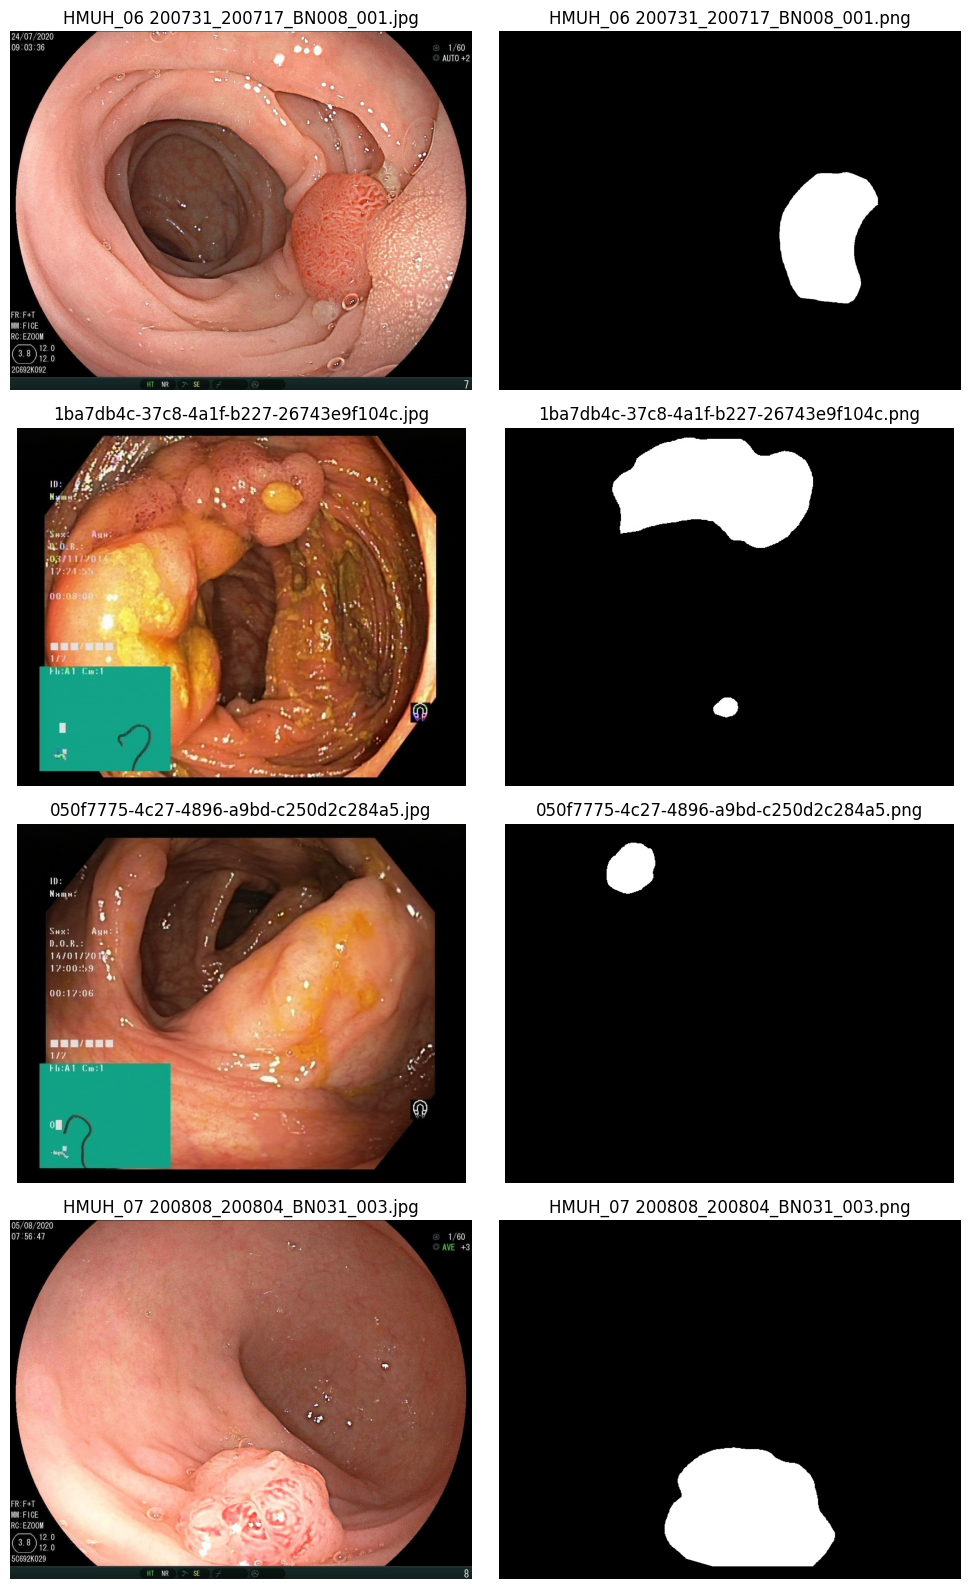

In [ ]:
def show_samples(pairs, n=4):
    n = min(n, len(pairs))
    sample_pairs = random.sample(pairs, n)

    plt.figure(figsize=(10, 4 * n))
    for i, (img_path, mask_path) in enumerate(sample_pairs):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(n, 2, 2*i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(img_path))
        plt.axis("off")

        plt.subplot(n, 2, 2*i + 2)
        plt.imshow(mask, cmap="gray")
        plt.title(os.path.basename(mask_path))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(pairs, n=4)

## Block 8 — Train/validation split

In [ ]:
train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=VAL_SPLIT,
    random_state=SEED,
    shuffle=True
)

train_df = pd.DataFrame(train_pairs, columns=["image_path", "mask_path"])
val_df   = pd.DataFrame(val_pairs, columns=["image_path", "mask_path"])

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))

train_df.to_csv("train_polypdb.csv", index=False)
val_df.to_csv("val_polypdb.csv", index=False)

Train samples: 2870
Val samples: 718


## Block 9 — Dataset and DataLoaders

In [ ]:
class PolypDataset(Dataset):
    def __init__(self, df, img_size=352, augment=False):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size

        if augment:
            self.transforms = A.Compose([
                A.Resize(img_size, img_size),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.2),
                A.RandomRotate90(p=0.3),
                A.ShiftScaleRotate(
                    shift_limit=0.05,
                    scale_limit=0.05,
                    rotate_limit=20,
                    border_mode=cv2.BORDER_CONSTANT,
                    p=0.5
                ),
                A.Normalize()
            ])
        else:
            self.transforms = A.Compose([
                A.Resize(img_size, img_size),
                A.Normalize()
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        mask_path = self.df.loc[idx, "mask_path"]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)

        transformed = self.transforms(image=image, mask=mask)
        image = transformed["image"]
        mask = transformed["mask"]

        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return {
            "image": image,
            "mask": mask,
            "img_path": img_path,
            "mask_path": mask_path
        }

train_dataset = PolypDataset(train_df, img_size=IMG_SIZE, augment=True)
val_dataset   = PolypDataset(val_df, img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 359
Val batches: 90


## Block 10 — Clone PraNet repository

If the repo changes in the future, this is the first place to inspect.

In [ ]:
if not os.path.exists("/content/PraNet"):
    !git clone https://github.com/DengPingFan/PraNet.git /content/PraNet

import sys
sys.path.append("/content/PraNet")

!ls /content/PraNet
!ls /content/PraNet/lib

Cloning into '/content/PraNet'...
remote: Enumerating objects: 1021, done.
remote: Counting objects: 100% (134/134), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 1021 (delta 93), reused 79 (delta 58), pack-reused 887 (from 1)
Receiving objects: 100% (1021/1021), 13.23 MiB | 46.08 MiB/s, done.
Resolving deltas: 100% (180/180), done.
eval  imgs  jittor  lib  MyTest.py  MyTrain.py	README.md  utils
PraNet_Res2Net.py  PraNet_ResNet.py  Res2Net_v1b.py  ResNet.py


## Block 11 — Import PraNet model

This block tries the most common import locations.

In [ ]:
# =========================
# FIX BLOCK — overwrite broken Res2Net_v1b.py
# =========================
from pathlib import Path

fixed_res2net_code = r'''
import torch
import torch.nn as nn
import math
import torch.utils.model_zoo as model_zoo

__all__ = ['Res2Net', 'res2net50_v1b', 'res2net101_v1b', 'res2net50_v1b_26w_4s',
           'res2net101_v1b_26w_4s', 'res2net152_v1b_26w_4s']

model_urls = {
    'res2net50_v1b_26w_4s': 'https://shanghuagao.oss-cn-beijing.aliyuncs.com/res2net/res2net50_v1b_26w_4s-3cf99910.pth',
    'res2net101_v1b_26w_4s': 'https://shanghuagao.oss-cn-beijing.aliyuncs.com/res2net/res2net101_v1b_26w_4s-0812c246.pth',
    'res2net152_v1b_26w_4s': 'https://shanghuagao.oss-cn-beijing.aliyuncs.com/res2net/res2net152_v1b_26w_4s-7c7c9dee.pth',
}

class Bottle2neck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None, baseWidth=26, scale=4, stype='normal'):
        super(Bottle2neck, self).__init__()

        width = int(math.floor(planes * (baseWidth / 64.0)))
        self.conv1 = nn.Conv2d(inplanes, width * scale, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(width * scale)

        if scale == 1:
            self.nums = 1
        else:
            self.nums = scale - 1

        if stype == 'stage':
            self.pool = nn.AvgPool2d(kernel_size=3, stride=stride, padding=1)

        convs = []
        bns = []
        for i in range(self.nums):
            convs.append(nn.Conv2d(width, width, kernel_size=3, stride=stride, padding=1, bias=False))
            bns.append(nn.BatchNorm2d(width))
        self.convs = nn.ModuleList(convs)
        self.bns = nn.ModuleList(bns)

        self.conv3 = nn.Conv2d(width * scale, planes * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stype = stype
        self.scale = scale
        self.width = width
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        spx = torch.split(out, self.width, 1)
        for i in range(self.nums):
            if i == 0 or self.stype == 'stage':
                sp = spx[i]
            else:
                sp = sp + spx[i]
            sp = self.convs[i](sp)
            sp = self.relu(self.bns[i](sp))
            if i == 0:
                out_ = sp
            else:
                out_ = torch.cat((out_, sp), 1)

        if self.scale != 1 and self.stype == 'normal':
            out_ = torch.cat((out_, spx[self.nums]), 1)
        elif self.scale != 1 and self.stype == 'stage':
            out_ = torch.cat((out_, self.pool(spx[self.nums])), 1)

        out = self.conv3(out_)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out

class Res2Net(nn.Module):
    def __init__(self, block, layers, baseWidth=26, scale=4, num_classes=1000):
        self.inplanes = 64
        super(Res2Net, self).__init__()
        self.baseWidth = baseWidth
        self.scale = scale

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, 1, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, 1, 1, bias=False)
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.AvgPool2d(kernel_size=stride, stride=stride, ceil_mode=True, count_include_pad=False),
                nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=1, stride=1, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample=downsample,
                            stype='stage', baseWidth=self.baseWidth, scale=self.scale))
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes, baseWidth=self.baseWidth, scale=self.scale))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

def _safe_load(model, url, pretrained=False):
    if pretrained:
        try:
            state_dict = model_zoo.load_url(url)
            model.load_state_dict(state_dict)
            print(f"Loaded pretrained weights from: {url}")
        except Exception as e:
            print(f"Warning: pretrained weights could not be loaded: {e}")
            print("Continuing with random initialization.")
    return model

def res2net50_v1b(pretrained=False, **kwargs):
    model = Res2Net(Bottle2neck, [3, 4, 6, 3], baseWidth=26, scale=4, **kwargs)
    return _safe_load(model, model_urls['res2net50_v1b_26w_4s'], pretrained=pretrained)

def res2net101_v1b(pretrained=False, **kwargs):
    model = Res2Net(Bottle2neck, [3, 4, 23, 3], baseWidth=26, scale=4, **kwargs)
    return _safe_load(model, model_urls['res2net101_v1b_26w_4s'], pretrained=pretrained)

def res2net50_v1b_26w_4s(pretrained=False, **kwargs):
    model = Res2Net(Bottle2neck, [3, 4, 6, 3], baseWidth=26, scale=4, **kwargs)
    return _safe_load(model, model_urls['res2net50_v1b_26w_4s'], pretrained=pretrained)

def res2net101_v1b_26w_4s(pretrained=False, **kwargs):
    model = Res2Net(Bottle2neck, [3, 4, 23, 3], baseWidth=26, scale=4, **kwargs)
    return _safe_load(model, model_urls['res2net101_v1b_26w_4s'], pretrained=pretrained)

def res2net152_v1b_26w_4s(pretrained=False, **kwargs):
    model = Res2Net(Bottle2neck, [3, 8, 36, 3], baseWidth=26, scale=4, **kwargs)
    return _safe_load(model, model_urls['res2net152_v1b_26w_4s'], pretrained=pretrained)
'''

target = Path("/content/PraNet/lib/Res2Net_v1b.py")
target.write_text(fixed_res2net_code, encoding="utf-8")
print("Rewritten:", target)

Rewritten: /content/PraNet/lib/Res2Net_v1b.py


In [ ]:
# RELOAD BLOCK — clear cached modules and import again

import sys
import importlib
import torch

mods_to_delete = [m for m in sys.modules if m.startswith("lib.") or m.startswith("PraNet.")]
for m in mods_to_delete:
    del sys.modules[m]

sys.path.insert(0, "/content/PraNet")

from lib.PraNet_Res2Net import PraNet

try:
    model = PraNet().to(device)
except TypeError:
    model = PraNet(channel=32).to(device)

print("PraNet imported successfully.")
print(type(model))

Downloading: "https://shanghuagao.oss-cn-beijing.aliyuncs.com/res2net/res2net50_v1b_26w_4s-3cf99910.pth" to /root/.cache/torch/hub/checkpoints/res2net50_v1b_26w_4s-3cf99910.pth


100%|██████████| 98.4M/98.4M [00:08<00:00, 12.5MB/s]


Loaded pretrained weights from: https://shanghuagao.oss-cn-beijing.aliyuncs.com/res2net/res2net50_v1b_26w_4s-3cf99910.pth
PraNet imported successfully.
<class 'lib.PraNet_Res2Net.PraNet'>


## Block 12 — Loss and metrics

In [ ]:
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss_from_logits(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(2, 3))
    den = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + eps
    dice = num / den
    return 1 - dice.mean()

def structure_loss(logits, mask):
    return bce_loss(logits, mask) + dice_loss_from_logits(logits, mask)

@torch.no_grad()
def compute_binary_metrics(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    tp = (preds * targets).sum(dim=(2, 3))
    fp = (preds * (1 - targets)).sum(dim=(2, 3))
    fn = ((1 - preds) * targets).sum(dim=(2, 3))

    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)

    return {
        "dice": dice.mean().item(),
        "iou": iou.mean().item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item(),
    }

## Block 13 — Training and validation functions

If shape mismatches happen, debug them here first.

In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc="Training", leave=False):
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)

        if isinstance(outputs, (list, tuple)) and len(outputs) == 4:
            lateral_map_5, lateral_map_4, lateral_map_3, lateral_map_2 = outputs
            loss = (
                structure_loss(lateral_map_5, masks) +
                structure_loss(lateral_map_4, masks) +
                structure_loss(lateral_map_3, masks) +
                structure_loss(lateral_map_2, masks)
            )
        else:
            loss = structure_loss(outputs, masks)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / max(len(loader), 1)

@torch.no_grad()
def validate_one_epoch(model, loader, device):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_precision = 0.0
    total_recall = 0.0

    for batch in tqdm(loader, desc="Validation", leave=False):
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        outputs = model(images)

        if isinstance(outputs, (list, tuple)) and len(outputs) == 4:
            lateral_map_5, lateral_map_4, lateral_map_3, lateral_map_2 = outputs
            loss = (
                structure_loss(lateral_map_5, masks) +
                structure_loss(lateral_map_4, masks) +
                structure_loss(lateral_map_3, masks) +
                structure_loss(lateral_map_2, masks)
            )
            logits = lateral_map_2
        else:
            loss = structure_loss(outputs, masks)
            logits = outputs

        m = compute_binary_metrics(logits, masks, threshold=THRESHOLD)
        total_loss += loss.item()
        total_dice += m["dice"]
        total_iou += m["iou"]
        total_precision += m["precision"]
        total_recall += m["recall"]

    n = max(len(loader), 1)
    return {
        "val_loss": total_loss / n,
        "val_dice": total_dice / n,
        "val_iou": total_iou / n,
        "val_precision": total_precision / n,
        "val_recall": total_recall / n,
    }

## Block 14 — Optimizer

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
print("Optimizer ready.")

Optimizer ready.


## Block 15 — Training loop

This is the main training block. It saves the best weights automatically.

In [ ]:
history = []
best_dice = -1.0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, device)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        **val_metrics
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['val_loss']:.4f} | "
        f"val_dice={val_metrics['val_dice']:.4f} | "
        f"val_iou={val_metrics['val_iou']:.4f} | "
        f"val_precision={val_metrics['val_precision']:.4f} | "
        f"val_recall={val_metrics['val_recall']:.4f}"
    )

    if val_metrics["val_dice"] > best_dice:
        best_dice = val_metrics["val_dice"]
        torch.save(model.state_dict(), "pranet_polypdb_best.pth")
        print("Saved best model.")

history_df = pd.DataFrame(history)
history_df.to_csv("pranet_training_history.csv", index=False)

summary_metrics = {
    "best_val_dice": float(history_df["val_dice"].max()),
    "best_val_iou": float(history_df["val_iou"].max()),
    "best_val_precision": float(history_df["val_precision"].max()),
    "best_val_recall": float(history_df["val_recall"].max()),
    "last_epoch": int(history_df["epoch"].iloc[-1]),
    "total_epochs": int(EPOCHS),
    "img_size": int(IMG_SIZE),
    "batch_size": int(BATCH_SIZE),
    "learning_rate": float(LR),
    "train_samples": int(len(train_df)),
    "val_samples": int(len(val_df)),
}

with open("pranet_summary_metrics.json", "w") as f:
    json.dump(summary_metrics, f, indent=2)

print(json.dumps(summary_metrics, indent=2))

Epoch 01/100 | train_loss=3.0807 | val_loss=2.4874 | val_dice=0.8187 | val_iou=0.7245 | val_precision=0.7664 | val_recall=0.9394
Saved best model.


Epoch 02/100 | train_loss=1.9195 | val_loss=1.5706 | val_dice=0.8652 | val_iou=0.7947 | val_precision=0.8924 | val_recall=0.8830
Saved best model.


Epoch 03/100 | train_loss=1.4877 | val_loss=1.3052 | val_dice=0.8740 | val_iou=0.8028 | val_precision=0.8729 | val_recall=0.9129
Saved best model.


Epoch 04/100 | train_loss=1.2040 | val_loss=1.1362 | val_dice=0.8748 | val_iou=0.8042 | val_precision=0.8686 | val_recall=0.9193
Saved best model.


Epoch 05/100 | train_loss=0.9870 | val_loss=0.9281 | val_dice=0.8899 | val_iou=0.8254 | val_precision=0.8815 | val_recall=0.9309
Saved best model.


...

Epoch 96/100 | train_loss=0.3000 | val_loss=0.7003 | val_dice=0.9117 | val_iou=0.8609 | val_precision=0.9351 | val_recall=0.9123


Epoch 97/100 | train_loss=0.3250 | val_loss=0.7673 | val_dice=0.9043 | val_iou=0.8459 | val_precision=0.9034 | val_recall=0.9310


Epoch 98/100 | train_loss=0.3553 | val_loss=0.6985 | val_dice=0.9117 | val_iou=0.8573 | val_precision=0.9344 | val_recall=0.9093


Epoch 99/100 | train_loss=0.3252 | val_loss=0.6834 | val_dice=0.9134 | val_iou=0.8595 | val_precision=0.9207 | val_recall=0.9237


Epoch 100/100 | train_loss=0.3718 | val_loss=0.6946 | val_dice=0.9109 | val_iou=0.8567 | val_precision=0.9280 | val_recall=0.9165
{
  "best_val_dice": 0.917095242606269,
  "best_val_iou": 0.8634314960903592,
  "best_val_precision": 0.9451416214307149,
  "best_val_recall": 0.9394380331039429,
  "last_epoch": 100,
  "total_epochs": 100,
  "img_size": 352,
  "batch_size": 8,
  "learning_rate": 0.0001,
  "train_samples": 2870,
  "val_samples": 718
}


## Block 16 — Plot curves

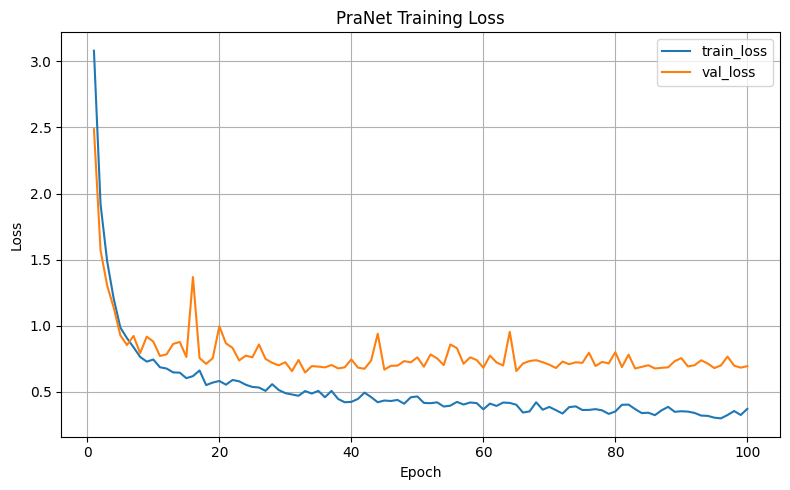

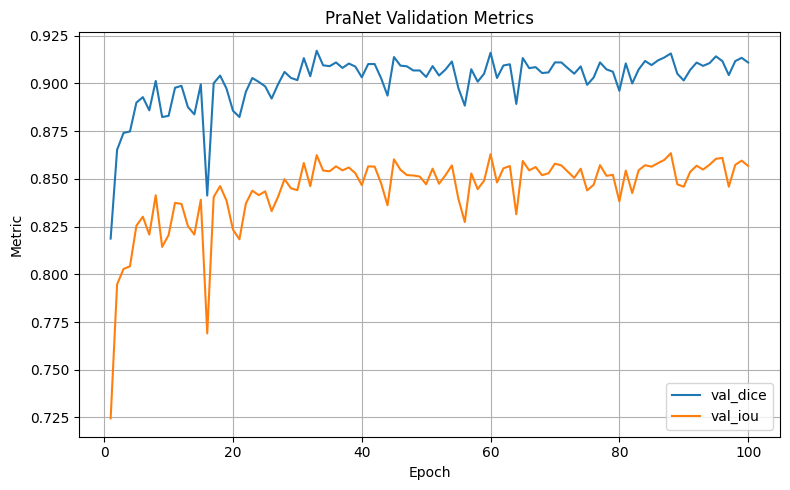

In [ ]:
history_df = pd.read_csv("pranet_training_history.csv")

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PraNet Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pranet_loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_dice"], label="val_dice")
plt.plot(history_df["epoch"], history_df["val_iou"], label="val_iou")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("PraNet Validation Metrics")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pranet_val_metrics_curve.png", dpi=200)
plt.show()

## Block 17 — Visualize predictions

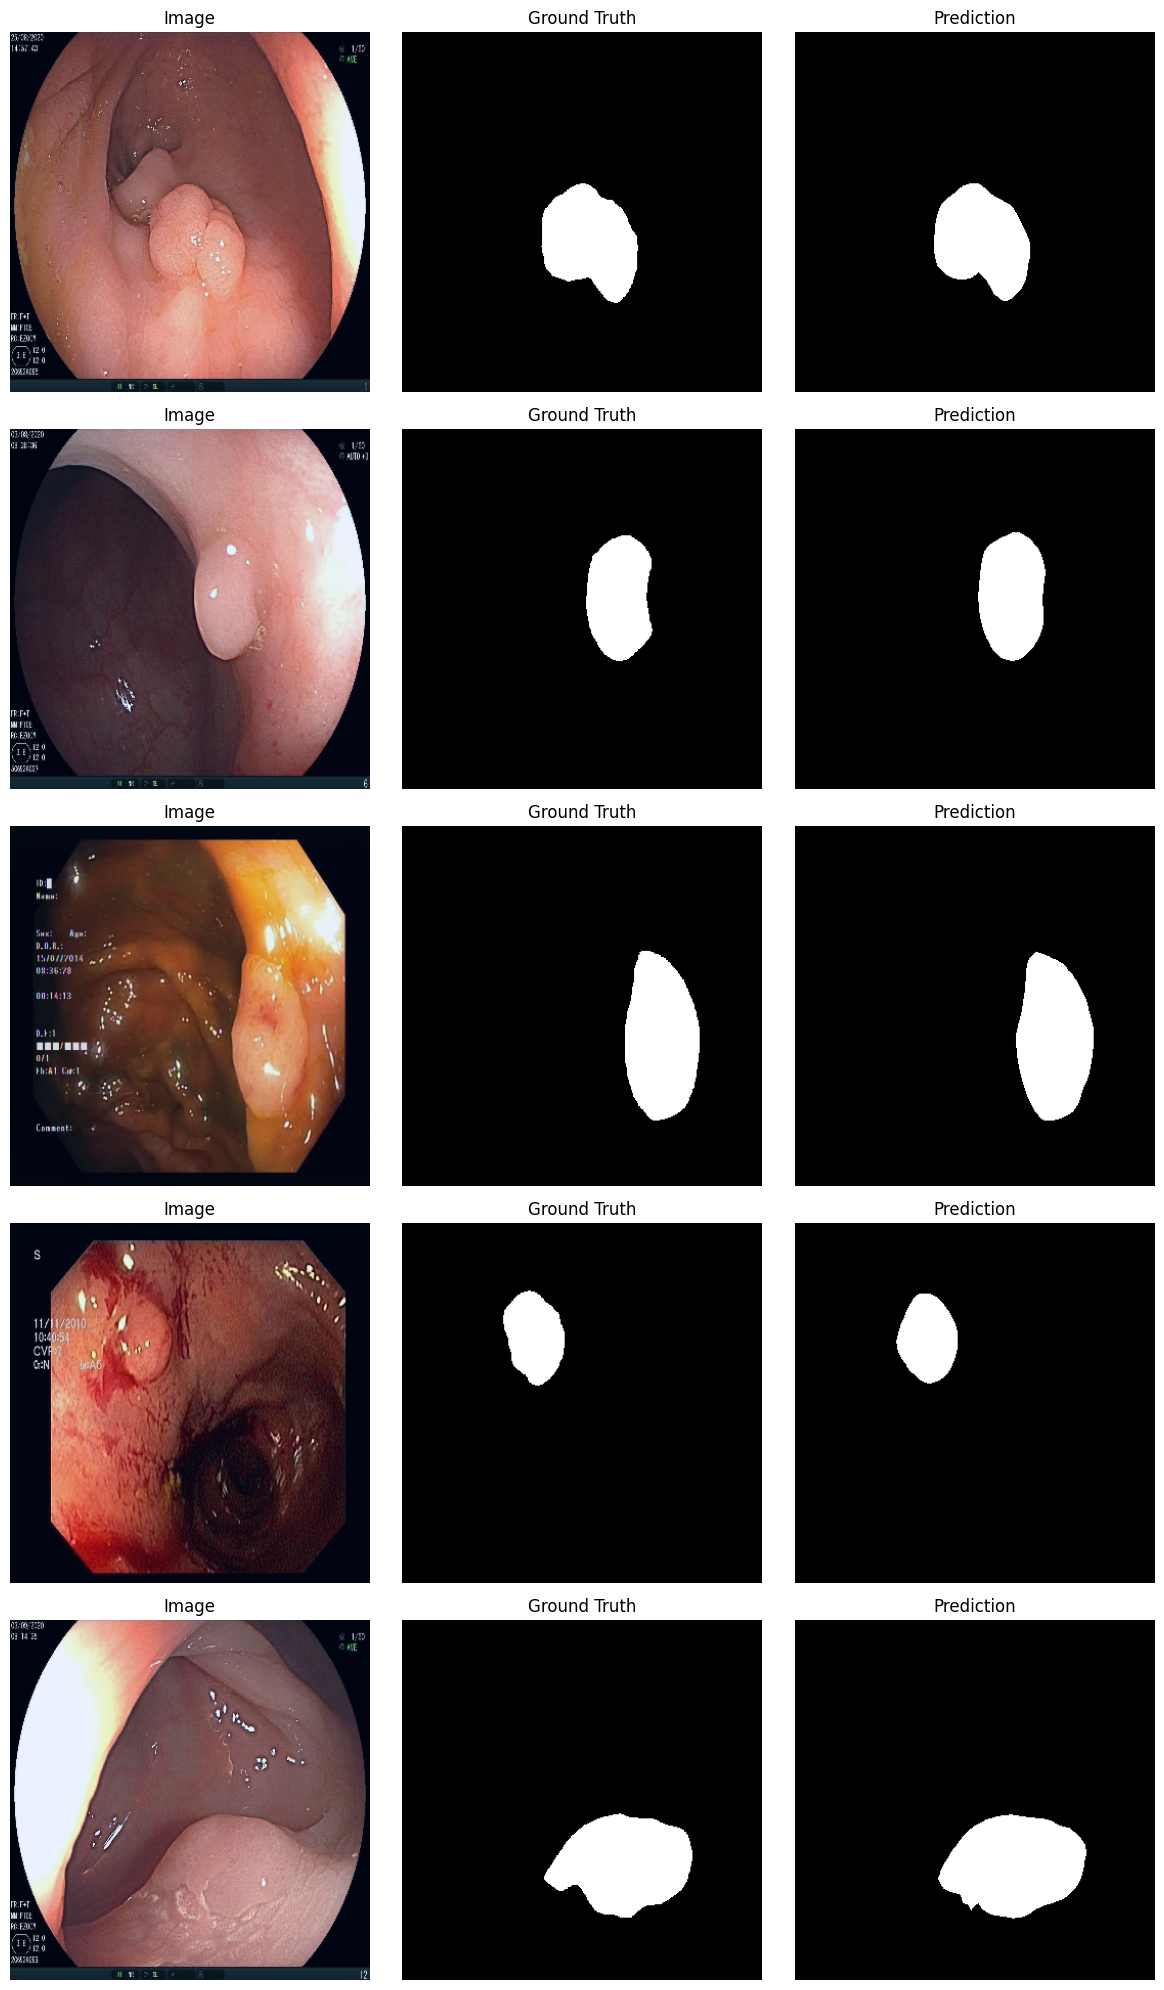

In [ ]:
@torch.no_grad()
def show_predictions(model, loader, device, num_samples=5, threshold=0.5, save_name="pranet_predictions_preview.png"):
    model.eval()
    batch = next(iter(loader))

    images = batch["image"].to(device)
    masks = batch["mask"].to(device)

    outputs = model(images)
    if isinstance(outputs, (list, tuple)) and len(outputs) == 4:
        logits = outputs[-1]
    else:
        logits = outputs

    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    images_np = images.cpu().permute(0, 2, 3, 1).numpy()
    masks_np = masks.cpu().squeeze(1).numpy()
    preds_np = preds.cpu().squeeze(1).numpy()

    n = min(num_samples, len(images_np))
    plt.figure(figsize=(12, 4 * n))

    for i in range(n):
        img = images_np[i]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        plt.subplot(n, 3, 3*i + 1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(n, 3, 3*i + 2)
        plt.imshow(masks_np[i], cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(n, 3, 3*i + 3)
        plt.imshow(preds_np[i], cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(save_name, dpi=200)
    plt.show()

show_predictions(model, val_loader, device, num_samples=5, threshold=THRESHOLD)

## Block 18 — Package outputs

In [ ]:
bundle_files = [
    "pranet_polypdb_best.pth",
    "pranet_training_history.csv",
    "pranet_summary_metrics.json",
    "pranet_loss_curve.png",
    "pranet_val_metrics_curve.png",
    "pranet_predictions_preview.png",
    "train_polypdb.csv",
    "val_polypdb.csv",
]

zip_name = "pranet_results_bundle.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in bundle_files:
        if os.path.exists(fname):
            zf.write(fname)

print("Created:", zip_name)

Created: pranet_results_bundle.zip


## Block 19 — Download results to your local machine

In [ ]:
to_download = [
    "pranet_polypdb_best.pth",
    "pranet_training_history.csv",
    "pranet_summary_metrics.json",
    "pranet_results_bundle.zip",
    "pranet_loss_curve.png",
    "pranet_val_metrics_curve.png",
    "pranet_predictions_preview.png",
]

for fname in to_download:
    if os.path.exists(fname):
        print("Downloading:", fname)
        files.download(fname)
    else:
        print("Missing:", fname)

Downloading: pranet_polypdb_best.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: pranet_training_history.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: pranet_predictions_preview.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Optional debug block — Check tensor shapes

Run this only if you suspect a shape mismatch between the model output and the masks.

In [ ]:
batch = next(iter(train_loader))
images = batch["image"].to(device)
masks = batch["mask"].to(device)

print("images:", images.shape)
print("masks :", masks.shape)

outputs = model(images)

if isinstance(outputs, (list, tuple)):
    print("Number of outputs:", len(outputs))
    for i, out in enumerate(outputs):
        print(f"output[{i}] shape:", out.shape)
else:
    print("output shape:", outputs.shape)

images: torch.Size([8, 3, 352, 352])
masks : torch.Size([8, 1, 352, 352])
Number of outputs: 4
output[0] shape: torch.Size([8, 1, 352, 352])
output[1] shape: torch.Size([8, 1, 352, 352])
output[2] shape: torch.Size([8, 1, 352, 352])
output[3] shape: torch.Size([8, 1, 352, 352])


## Download

In [ ]:
# SAVE + DOWNLOAD EVERYTHING

import os
import json
import zipfile
import pandas as pd
from google.colab import files

OUTPUT_DIR = "/content/results_pranet"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# SAVE MODEL WEIGHTS

model_path = os.path.join(OUTPUT_DIR, "pranet_best.pt")
torch.save(model.state_dict(), model_path)
print("Model saved:", model_path)


# SAVE TRAINING HISTORY

history = pd.DataFrame({
    "epoch": list(range(1, len(train_losses)+1)),
    "train_loss": train_losses,
    "val_dice": val_dices
})

history_csv = os.path.join(OUTPUT_DIR, "training_history.csv")
history_xlsx = os.path.join(OUTPUT_DIR, "training_history.xlsx")

history.to_csv(history_csv, index=False)
history.to_excel(history_xlsx, index=False)

print("Metrics saved")


# 3 SAVE SUMMARY METRICS

summary = {
    "best_dice": max(val_dices),
    "final_dice": val_dices[-1],
    "epochs": len(val_dices)
}

summary_path = os.path.join(OUTPUT_DIR, "summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

print("Summary saved")


# 4. ZIP EVERYTHING

zip_path = "/content/pranet_results_bundle.zip"

with zipfile.ZipFile(zip_path, 'w') as zipf:
    for root, dirs, files_ in os.walk(OUTPUT_DIR):
        for file in files_:
            full_path = os.path.join(root, file)
            zipf.write(full_path, arcname=file)

print("ZIP ready:", zip_path)


# 5. DOWNLOAD TO LOCAL PC

files.download(zip_path)